In [3]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

!pip install -q -U \
    "protobuf>=5.29,<6.0" \
    "bitsandbytes>=0.45.0" \
    "transformers==4.46.3" \
    "peft==0.13.2" \
    "trl==0.12.1" \
    "accelerate==1.1.1" \
    "datasets==3.1.0" \
    "wandb" \
    "sentencepiece"

In [4]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"

import torch
import numpy as np
import json
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from collections import Counter
import matplotlib.pyplot as plt

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: Tesla T4


In [1]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import torch
import numpy as np
from datasets import load_dataset, Dataset, load_from_disk
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)


In [5]:
model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.special_tokens_map}")

Tokenizer vocab size: 151643
Special tokens: {'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}


In [6]:
ds = load_dataset("open-r1/OpenR1-Math-220k", split="train")
print(f"Total examples: {len(ds):,}")
print(f"Columns: {ds.column_names}")
print(f"\nFirst example structure:")
print(json.dumps({k: str(v)[:200] + "..." if len(str(v)) > 200 else v 
                  for k, v in ds[0].items()}, indent=2))

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Total examples: 93,733
Columns: ['problem', 'solution', 'answer', 'problem_type', 'question_type', 'source', 'uuid', 'is_reasoning_complete', 'generations', 'correctness_math_verify', 'correctness_llama', 'finish_reasons', 'correctness_count', 'messages']

First example structure:
{
  "problem": "## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$...",
  "solution": "## Solution.\n\nLet $t$ be the time required for the boat to travel $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream, $v_{R}$ the speed of the river, and $v_{B}$ the speed of the boat. When t...",
  "answer": "v_{R}=4\\mathrm{~}/\\mathrm{},v_{B}=10\\mathrm{~}/\\mathrm{}",
  "problem_type": "Algebra",
  "question_type": "math-word-problem",
  "source": "olympiads",
  "uuid": "586fd646-76d6-5070-8c81-9993ab9d8559",
  "is_reasoning_complete": [
    true,
    tru

In [7]:
import random
random.seed(42)

sample_indices = random.sample(range(len(ds)), 5)
for idx in sample_indices:
    ex = ds[idx]
    print(f"\n{'='*80}")
    print(f"EXAMPLE {idx}")
    print('='*80)
    for key, value in ex.items():
        print(f"\n--- {key} ---")
        if isinstance(value, str):
            print(value[:1500])
            if len(value) > 1500:
                print(f"\n... [truncated, full length: {len(value)} chars]")
        else:
            print(value)


EXAMPLE 83810

--- problem ---
67. There are three steel pipes, with lengths of 240 cm, 200 cm, and 480 cm, respectively. If they are cut into segments of the same length, the longest each segment can be is $\qquad$ cm.

--- solution ---
Answer: 40

--- answer ---
40

--- problem_type ---
Number Theory

--- question_type ---
math-word-problem

--- source ---
olympiads

--- uuid ---
46081bc1-d391-5a38-8fd6-e20dd40278ae

--- is_reasoning_complete ---
[True, True]

--- generations ---
['<think>\nOkay, so I need to figure out the longest possible length that three steel pipes (240 cm, 200 cm, and 480 cm) can be cut into, such that all the resulting segments are the same length. Hmm. Let me think. \n\nFirst, when they say "cut into segments of the same length," that means each original pipe has to be divided into equal parts with no leftover material, right? So, the length of each segment has to divide evenly into each of the original pipe lengths. Therefore, the longest possible segment t

In [8]:
def quality_filter(example):
    """Keep examples where at least one generation is verified correct."""
    # Math verify is strictest, so preferred it
    math_verify = example.get('correctness_math_verify')
    if math_verify and any(math_verify):
        return True
    
    # Fall back to LLM judge if math verify unavailable
    llama_verify = example.get('correctness_llama')
    if llama_verify and any(llama_verify):
        return True
    
    return False

filtered_quality = ds.filter(quality_filter, num_proc=4)
print(f"After quality filter: {len(filtered_quality):,} ({100*len(filtered_quality)/len(ds):.1f}% retained)")

After quality filter: 93,733 (100.0% retained)


In [9]:
def expand_correct_generations(example):
    """Return one training example per VERIFIED CORRECT generation.
    Uses the messages field which is already chat-formatted."""
    math_verify = example.get('correctness_math_verify') or []
    llama_verify = example.get('correctness_llama') or []
    generations = example.get('generations', [])
    
    expanded = []
    for i, gen in enumerate(generations):
        # Prefer math_verify, fall back to llama
        is_correct = False
        if i < len(math_verify) and math_verify[i] is not None:
            is_correct = math_verify[i]
        elif i < len(llama_verify) and llama_verify[i] is not None:
            is_correct = llama_verify[i]
        
        if is_correct:
            expanded.append({
                'problem': example['problem'],
                'generation': gen,
                'answer': example['answer'],
                'source': example.get('source', 'unknown'),
            })
    return expanded

# Flatten: each correct generation becomes a row
expanded_rows = []
for ex in filtered_quality:
    expanded_rows.extend(expand_correct_generations(ex))

print(f"Expanded to {len(expanded_rows):,} training examples (from {len(filtered_quality):,} problems)")

from datasets import Dataset
expanded_ds = Dataset.from_list(expanded_rows)

Expanded to 124,445 training examples (from 93,733 problems)


In [10]:
expanded_ds.save_to_disk("/kaggle/working/expanded_ds")
print(f"Saved {len(expanded_ds)} examples to disk")

Saving the dataset (0/5 shards):   0%|          | 0/124445 [00:00<?, ? examples/s]

Saved 124445 examples to disk


  Tokenized 100/1000...
  Tokenized 200/1000...
  Tokenized 300/1000...
  Tokenized 400/1000...
  Tokenized 500/1000...
  Tokenized 600/1000...
  Tokenized 700/1000...
  Tokenized 800/1000...
  Tokenized 900/1000...
  Tokenized 1000/1000...

Token length stats (n=1000):
  Median: 4843
  Mean:   5913
  p75:    7870
  p90:    11731
  p95:    14080
  p99:    17171
  Max:    19296


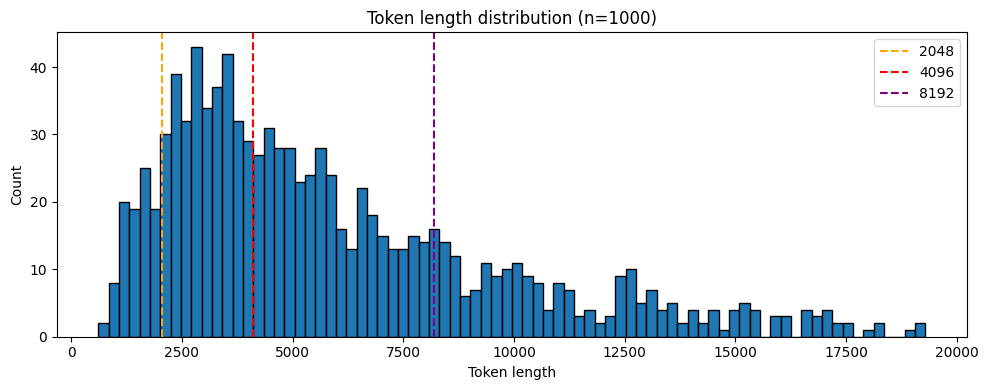

In [11]:
sample_size = 1000
sample = expanded_ds.shuffle(seed=42).select(range(sample_size))

# Manual loop instead of .map() — more memory-efficient
lengths = []
for i, ex in enumerate(sample):
    messages = [
        {"role": "user", "content": ex['problem']},
        {"role": "assistant", "content": ex['generation']}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    tokens = tokenizer.encode(text, add_special_tokens=False)
    lengths.append(len(tokens))
    
    if (i + 1) % 100 == 0:
        print(f"  Tokenized {i+1}/{sample_size}...")

lengths = np.array(lengths)

print(f"\nToken length stats (n={len(lengths)}):")
print(f"  Median: {np.median(lengths):.0f}")
print(f"  Mean:   {np.mean(lengths):.0f}")
print(f"  p75:    {np.percentile(lengths, 75):.0f}")
print(f"  p90:    {np.percentile(lengths, 90):.0f}")
print(f"  p95:    {np.percentile(lengths, 95):.0f}")
print(f"  p99:    {np.percentile(lengths, 99):.0f}")
print(f"  Max:    {np.max(lengths)}")

# Plot
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=80, edgecolor='black')
plt.axvline(2048, color='orange', linestyle='--', label='2048')
plt.axvline(4096, color='red', linestyle='--', label='4096')
plt.axvline(8192, color='purple', linestyle='--', label='8192')
plt.xlabel('Token length')
plt.ylabel('Count')
plt.title(f'Token length distribution (n={len(lengths)})')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/token_length_dist.png', dpi=100)
plt.show()

In [12]:
MAX_TOKENS = 4096
N_TRAIN = 20000
BATCH_SIZE = 1
GRAD_ACCUM = 32  
EXPECTED_TOKENS_PER_BATCH = 4096

In [13]:
# Length filter
MAX_TOKENS = 4096

def length_filter(example):
    messages = [
        {"role": "user", "content": example['problem']},
        {"role": "assistant", "content": example['generation']}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return len(tokens) <= MAX_TOKENS

# Single-process
length_filtered = expanded_ds.filter(length_filter)
print(f"After length filter (<={MAX_TOKENS}): {len(length_filtered):,} "
      f"({100*len(length_filtered)/len(expanded_ds):.1f}% retained)")

Filter:   0%|          | 0/124445 [00:00<?, ? examples/s]

After length filter (<=4096): 51,802 (41.6% retained)


In [14]:
def format_for_training(example):
    messages = [
        {"role": "user", "content": example['problem']},
        {"role": "assistant", "content": example['generation']}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

formatted = length_filtered.map(format_for_training)  # No num_proc

N_TRAIN = min(20000, len(formatted))
final = formatted.shuffle(seed=42).select(range(N_TRAIN))
splits = final.train_test_split(test_size=0.02, seed=42)

train_ds = splits['train']
val_ds = splits['test']

# Drop the text-heavy columns we don't need for training to save disk
keep_cols = ['text']
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in keep_cols])
val_ds = val_ds.remove_columns([c for c in val_ds.column_names if c not in keep_cols])

train_ds.save_to_disk("/kaggle/working/train_ds")
val_ds.save_to_disk("/kaggle/working/val_ds")
print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

Map:   0%|          | 0/51802 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/19600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/400 [00:00<?, ? examples/s]

Train: 19,600 | Val: 400


In [15]:
print("="*80)
print("FORMATTED EXAMPLE (what model sees during training)")
print("="*80)
print(train_ds[0]['text'][:2500])
print(f"\n... [total chars: {len(train_ds[0]['text'])}]")

FORMATTED EXAMPLE (what model sees during training)
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
From time $t=0$ to time $t=1$ a population increased by $i\%$, and from time $t=1$ to time $t=2$ the population increased by $j\%$. Therefore, from time $t=0$ to time $t=2$ the population increased by
$\text{(A) (i+j)\%} \quad \text{(B) } ij\%\quad \text{(C) } (i+ij)\%\quad \text{(D) } \left(i+j+\frac{ij}{100}\right)\%\quad \text{(E) } \left(i+j+\frac{i+j}{100}\right)\%$<|im_end|>
<|im_start|>assistant
<think>
Okay, let's see. The problem is about population growth over two time periods with different percentage increases each period. I need to find the overall percentage increase from time t=0 to t=2. The options are given, so maybe I can work through it step by step.

First, let me recall how percentage increases work. If something increases by i%, then the new amount is the original plus i% of the original. So mathemat